# Regularization in Deep Learning: L2 Regularization, L1 Regularization, and Weight Decay in ANNs

---

## 1. Executive Summary
This guide provides a structured breakdown of **Regularization Techniques** in Artificial Neural Networks (ANNs).

> **Key Takeaway:** Regularization is primarily used to prevent **overfitting** in complex models. By adding a penalty term to the cost function, it shrinks the network weights towards zero, reducing effective model capacity and forcing the network to learn generalized patterns rather than memorization.

---

## 2. Overfitting & Why ANNs Overfit

### What is Overfitting?
* **Definition:** A scenario where a machine learning or deep learning model performs exceptionally well on training data but poorly on unseen test data.
* **Behavior:** The model becomes overly complex, capturing minor patterns and noise in the training set instead of learning the underlying signal.

### Why ANNs are Prone to Overfitting
* Overfitting is strongly linked to **model capacity and architectural complexity**.
* As the number of neurons and layers increases, the network gains high-degree non-linear capacity to form intricate, highly sensitive decision boundaries.
* **Model Scale Progression:**
  * **1 Neuron (Perceptron):** Produces a single linear decision boundary.
  * **10–50 Neurons:** Generates moderately flexible curved decision boundaries.
  * **1000 Neurons:** Constructs highly complex, jagged decision boundaries tailored to fit every training noise point.

---

## 3. Strategies to Reduce Overfitting

1. **Increasing Data Volume:**
   * Collecting more real-world training instances.
   * **Data Augmentation:** Generating synthetic variations from existing samples (e.g., cropping, flipping, scaling images).
2. **Reducing Model Complexity:**
   * **Dropout:** Randomly deactivating a fixed percentage of neurons during each training pass.
   * **Early Stopping:** Halting training as soon as validation loss begins to diverge from training loss.
   * **Regularization ($L_1$ & $L_2$):** Penalizing large weight values within the loss function.

---

## 4. Mathematical Foundation of Regularization

Regularization alters the standard cost function $J(W, b)$ by attaching a **penalty term** scaled by a hyperparameter $\lambda$:

$$\text{Cost Function (Regularized)} = J(W, b) + \text{Penalty Term}$$

### $L_2$ Regularization (Ridge / Weight Decay)
$$\text{Cost Function} = J(W, b) + \frac{\lambda}{2n} \sum_{l=1}^{L} \vert{}\vert{}W^{[l]}\vert{}\vert{}_F^2$$

* **Penalty:** The sum of squared weights across all layers.
* **Hyperparameter $\lambda$ (Lambda):**
  * $\lambda \to 0$: Regularization penalty vanishes (reverts to standard loss).
  * $\lambda \to \text{Large}$: Over-penalizes weights towards zero, causing underfitting.
* **Handling Biases:** The penalty is applied **strictly to weights ($W$)**, not bias vectors ($b$), as biases do not contribute to network variance or structural complexity.

### $L_1$ Regularization (Lasso)
$$\text{Cost Function} = J(W, b) + \frac{\lambda}{2n} \sum \vert{}W\vert{}$$

* **Sparsity Property:** Forces non-essential weights directly to absolute zero, serving as an implicit feature selection mechanism.
* Creates sparse network representations but is generally less effective in deep neural networks compared to $L_2$.

---

## 5. Mathematical Intuition: Why Weights Decay

When updating weights using Gradient Descent:

$$\text{New Loss } (J') = J + \frac{\lambda}{2} W^2$$

Taking the partial derivative with respect to $W$:

$$\frac{\partial J'}{\partial W} = \frac{\partial J}{\partial W} + \lambda W$$

Substituting into the standard Gradient Descent update step:

$$W_{\text{new}} = W_{\text{old}} - \alpha \left( \frac{\partial J}{\partial W} + \lambda W \right)$$

$$W_{\text{new}} = W_{\text{old}} (1 - \alpha \lambda) - \alpha \frac{\partial J}{\partial W}$$

> **Core Mathematical Insight:** Because $(1 - \alpha \lambda) < 1$, the weight $W_{\text{old}}$ is scaled down by a fraction before subtracting the gradient step. This continuous reduction per iteration is why $L_2$ Regularization is referred to as **Weight Decay**.

---

## 6. Practical Implementation & Empirical Comparison

### TensorFlow / Keras Implementation
$L_2$ regularization can be applied directly to hidden layers using the `kernel_regularizer` argument:

```python
import tensorflow as tf
from tensorflow.keras import regularizers

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from mlxtend.plotting import plot_decision_regions 

from sklearn.datasets import make_moons 

import tensorflow 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense , Input, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
x,y = make_moons(
    100, 
    noise=0.25, 
    random_state=2
)

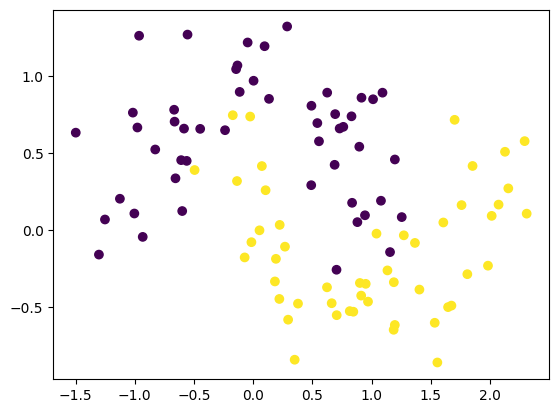

In [5]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [6]:
model1 = Sequential([
    Input(shape=(2,)), 
    Dense(128,activation="relu"), 
    Dense(128,activation="relu"), 
    Dense(1,activation="sigmoid")
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

hist1 = model1.fit(x,y,epochs=750,validation_split = 0.2 , verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step


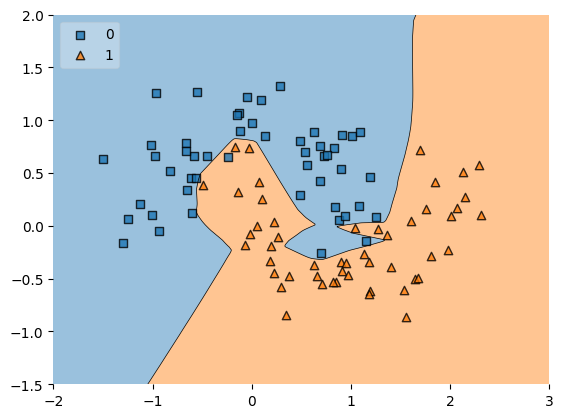

In [8]:
# Decision Boundary
plot_decision_regions(x, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

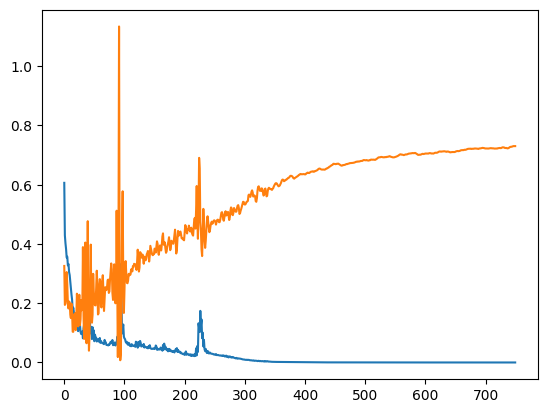

In [10]:
# Loss curve 
plt.plot(hist1.history['loss'])
plt.plot(hist1.history['val_loss']) ; 

### Training Model with L2 Regularization 

In [18]:
model2 = Sequential([
    Input(shape=(2,)), 
    Dense(128,activation="relu", kernel_regularizer = tensorflow.keras.regularizers.l2(0.03)), 
    Dense(128,activation="relu",  kernel_regularizer = tensorflow.keras.regularizers.l2(0.03) ), 
    Dense(1,activation="sigmoid")
])

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

hist2 = model2.fit(x,y,epochs=750,validation_split = 0.2 , verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step


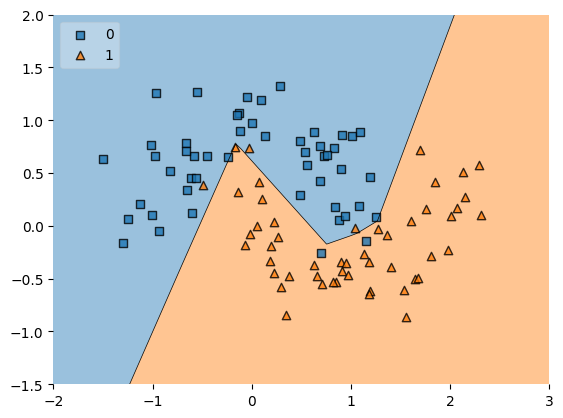

In [20]:
# Decision Boundary of L2 model
plot_decision_regions(x, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

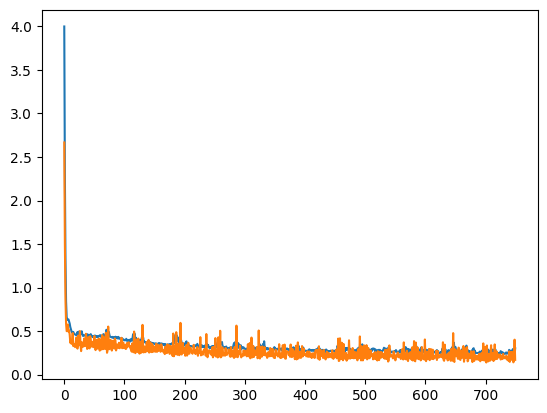

In [21]:
# Loss curve 
plt.plot(hist2.history['loss'])
plt.plot(hist2.history['val_loss']) ; 

### Training Model with L1 Regularization 

In [22]:
model3 = Sequential([
    Input(shape=(2,)), 
    Dense(128,activation="relu", kernel_regularizer = tensorflow.keras.regularizers.l1(0.001)), 
    Dense(128,activation="relu",  kernel_regularizer = tensorflow.keras.regularizers.l1(0.001) ), 
    Dense(1,activation="sigmoid")
])

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
adam = Adam(learning_rate=0.01)
model3.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

hist3 = model3.fit(x,y,epochs=750,validation_split = 0.2 , verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step


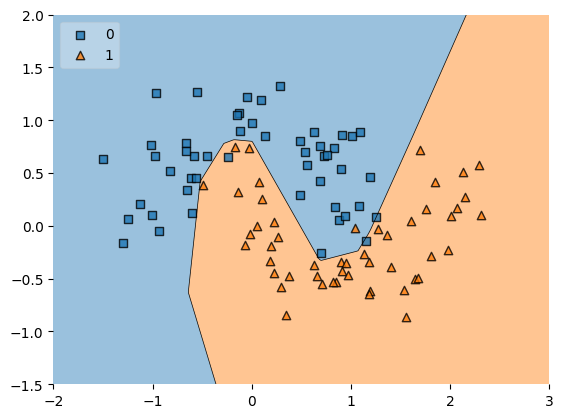

In [24]:
# Decision Boundary of L1 model
plot_decision_regions(x, y.astype('int'), clf=model3, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

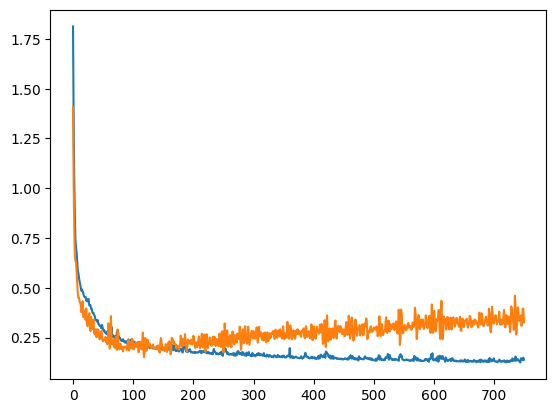

In [25]:
# Loss curve 
plt.plot(hist3.history['loss'])
plt.plot(hist3.history['val_loss'])

In [26]:
# lets see the distribution of the data after regularization 
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256) 
model3_weight_layer1 = model3.get_weights()[0].reshape(256) 

<Axes: >

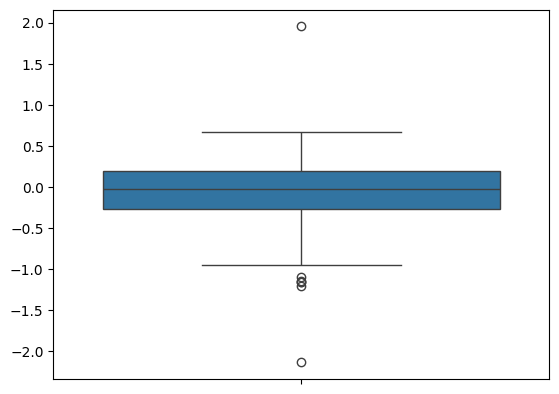

In [27]:
sns.boxplot(model1_weight_layer1)

<Axes: >

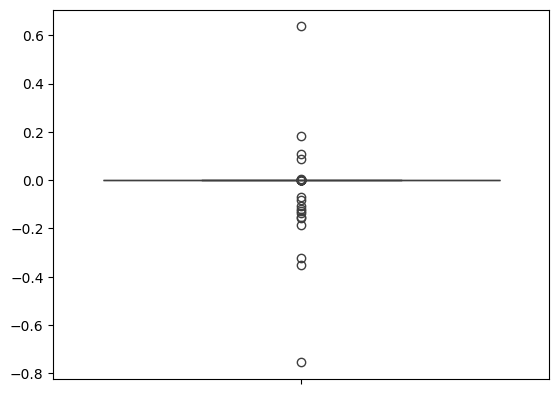

In [28]:
sns.boxplot(model2_weight_layer1)

<Axes: >

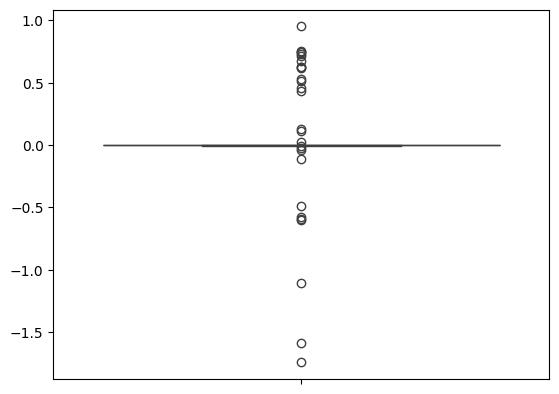

In [29]:
sns.boxplot(model3_weight_layer1)